# CE5033 期末專題 — 機車規格分析 
### 結合「統計方法」與「資料採礦」分析 42,564 台機車（資料來源：Bikez.com）

這份 notebook 是**自包含**的：直接讀入原始 `all_bikez_raw.csv`，清理後依序執行
**① 資料前處理 → ② 探索式分析(EDA) → ③ 統計方法 → ④ 資料採礦**，所有程式碼與圖表都在本檔內顯示。

**使用方式**：由上而下執行（`Kernel ▸ Restart & Run All`）。每個程式碼 cell 上方與行內都有中文註解說明。
完整的文字報告請見 `CE5033_FinalProject/REPORT.md`。

In [1]:
# ===== 環境設定 =====
# 匯入分析會用到的套件
import re, warnings                       # re=正則表達式(用來從文字中抽數字)；warnings=警告控制
import numpy as np                        # numpy=數值運算(陣列、數學函數)
import pandas as pd                       # pandas=資料表(DataFrame)處理
import matplotlib.pyplot as plt           # matplotlib=基礎繪圖
import seaborn as sns                     # seaborn=美化版統計繪圖
warnings.filterwarnings("ignore")         # 關閉警告訊息，讓 notebook 輸出乾淨
# 下一行為 IPython 魔術指令：讓圖表直接內嵌顯示在 cell 下方(注意：此行尾不可加註解)
%matplotlib inline

# 統一畫圖風格與表格顯示設定
sns.set_theme(style="whitegrid", context="notebook")  # 白底+網格的乾淨風格
plt.rcParams["figure.dpi"] = 100                       # 圖片解析度
pd.set_option("display.max_columns", 60)               # 表格最多顯示 60 欄
pd.set_option("display.width", 160)                    # 表格每列寬度

# 檔案路徑：本 notebook 與兩個 csv 都在 archive/ 內，所以用相對路徑即可
RAW_CSV    = "all_bikez_raw.csv"          # 原始機車規格資料(很髒、含單位文字)
BRANDS_CSV = "bikez_brands.csv"           # 官方品牌清單(400+ 個品牌)

# 分析用的常數(集中管理，方便調整)
RANDOM_STATE = 42      # 亂數種子：固定它，每次執行結果都一樣(可重現)
TEST_SIZE    = 0.25    # 分類時切出 25% 當測試集
TOP_N        = 8       # 只取數量最多的前 8 個車種來建模
ALPHA        = 0.05    # 假設檢定的顯著水準(p<0.05 視為顯著)
print("環境設定完成。")

環境設定完成。


## 1. 資料前處理 (Data Preprocessing) — *對應指示 #1*

原始檔很「髒」：每個數字都被包在含單位的文字裡（例如 `"241.5 ccm (14.74 cubic inches)"`、
`"23.1 HP (16.8 kW)) @ 8500 RPM"`），而且缺失值最高達 84%。本節把它**整理成乾淨的數值表**。

In [2]:
# ----- 1.1 載入原始資料，先看看它有多「亂」 -----
raw = pd.read_csv(RAW_CSV, low_memory=False)   # 讀 csv；low_memory=False 避免欄位型別判斷警告
print("原始資料維度 (列, 欄):", raw.shape)      # 應該是 (42564, 105)

# 挑幾個代表性欄位看實際內容 —— 注意數字都混在文字+單位裡，無法直接計算
raw[["Model","Category","Displacement","Power","Top speed","Bore x stroke","Cooling system"]].head(5)

原始資料維度 (列, 欄): (42564, 105)


,Model,Category,Displacement,Power,Top speed,Bore x stroke,Cooling system
0,Jonway X-Jet 250,Sport touring,241.5 ccm (14.74 cubic inches),23.1 HP (16.8 kW)) @ 8500 RPM,110.0 km/h (68.4 mph),NaN,Liquid
1,NaN,NaN,NaN,NaN,178.6 km/h (111.0 mph),107.1 x 100.0 mm (4.2 x 3.9 inches),Oil & air
2,NaN,NaN,NaN,NaN,NaN,69.0 x 61.1 mm (2.7 x 2.4 inches),Liquid
3,NaN,Enduro / offroad,124.8 ccm (7.62 cubic inches),NaN,NaN,54.0 x 54.5 mm (2.1 x 2.1 inches),Liquid
4,NaN,NaN,NaN,NaN,NaN,58.0 x 47.0 mm (2.3 x 1.9 inches),Liquid


In [3]:
# ----- 1.2 定義「正則表達式」解析器：把文字裡的數字抽出來(遇到缺失就回傳 NaN) -----

def num_before_unit(v, unit):
    # 抽出「單位前面」的數字，例如 num_before_unit("241.5 ccm ...", "ccm") -> 241.5
    if pd.isna(v):                                          # 若該格是空值
        return np.nan
    m = re.search(r"([0-9]+\.?[0-9]*)\s*" + re.escape(unit), str(v))  # 找「數字+單位」的樣式
    return float(m.group(1)) if m else np.nan              # 找到就轉成 float，否則 NaN

def rpm_after_at(v):
    # 抽出「@ 8500 RPM」中的轉速 -> 8500
    if pd.isna(v):
        return np.nan
    m = re.search(r"@\s*([0-9]+)\s*RPM", str(v))
    return float(m.group(1)) if m else np.nan

def bore_stroke(v):
    # 把「107.1 x 100.0 mm ...」拆成 (缸徑 bore, 行程 stroke) = (107.1, 100.0)
    if pd.isna(v):
        return (np.nan, np.nan)
    m = re.search(r"([0-9]+\.?[0-9]*)\s*x\s*([0-9]+\.?[0-9]*)\s*mm", str(v))
    return (float(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)

def compression_ratio(v):
    # 把壓縮比「9.6:1」抽成 9.6
    if pd.isna(v):
        return np.nan
    m = re.search(r"([0-9]+\.?[0-9]*)\s*:\s*1", str(v))
    return float(m.group(1)) if m else np.nan

def leading_float(v):
    # 抽出字串「開頭」的數字(評分用)：'3.3  Check out...' -> 3.3；若開頭不是數字(如'Do you know...')就回 NaN
    if pd.isna(v):
        return np.nan
    m = re.match(r"\s*([0-9]+\.?[0-9]*)", str(v))
    return float(m.group(1)) if m else np.nan

def clip_range(s, lo, hi):
    # 把超出合理範圍[lo, hi]的值視為「鍵入錯誤」,改成 NaN(例如乾重 0 公斤、極速 650 km/h)
    return s.where((s >= lo) & (s <= hi))

print("解析器函式定義完成。")

解析器函式定義完成。


In [4]:
# ----- 1.3 用上面的解析器，建立一張乾淨的「數值 + 類別」資料表 df -----

# 設定每個數值欄位的：(原始欄名, 單位關鍵字, (合理最小值, 合理最大值))
NUMERIC = {
 "displacement_ccm":  ("Displacement",       "ccm",   (25, 3000)),   # 排氣量
 "power_hp":          ("Power",              "HP",    (1, 400)),      # 馬力
 "torque_nm":         ("Torque",            "Nm",    (1, 600)),      # 扭力
 "top_speed_kmh":     ("Top speed",         "km/h",  (20, 450)),     # 極速
 "dry_weight_kg":     ("Dry weight",        "kg",    (20, 700)),     # 乾重
 "fuel_capacity_l":   ("Fuel capacity",     "litres",(1, 60)),       # 油箱容量
 "seat_height_mm":    ("Seat height",       "mm",    (400, 1100)),   # 座高
 "wheelbase_mm":      ("Wheelbase",         "mm",    (600, 2200)),   # 軸距
 "power_weight_ratio":("Power/weight ratio","HP/kg", (0.0, 3.0)),    # 馬力重量比
}
df = pd.DataFrame(index=raw.index)                     # 建立空表，沿用原始的列索引
for k, (col, unit, (lo, hi)) in NUMERIC.items():       # 逐一處理每個數值欄位
    parsed = raw[col].apply(lambda v: num_before_unit(v, unit))  # 抽數字
    df[k]  = clip_range(parsed, lo, hi)                # 去除不合理值

# 引擎轉速(馬力/扭力的峰值轉速)
df["power_rpm"]  = clip_range(raw["Power"].apply(rpm_after_at),  500, 25000)
df["torque_rpm"] = clip_range(raw["Torque"].apply(rpm_after_at), 100, 25000)
# 缸徑與行程(從同一欄拆成兩欄)
bs = raw["Bore x stroke"].apply(bore_stroke)
df["bore_mm"]   = clip_range(bs.apply(lambda t: t[0]), 20, 160)
df["stroke_mm"] = clip_range(bs.apply(lambda t: t[1]), 15, 160)
# 壓縮比、評分、年份
df["compression_ratio"] = clip_range(raw["Compression"].apply(compression_ratio), 4, 18)
df["rating"] = clip_range(raw["Rating"].apply(leading_float), 0, 5)
df["year"]   = clip_range(pd.to_numeric(raw["Year"], errors="coerce"), 1894, 2026)

# ----- 類別欄位清理 -----
def clean_fuel(v):
    # 把超亂的「供油系統」文字歸成四類：噴射/化油器/渦輪/其他
    if pd.isna(v):
        return np.nan
    h = str(v).split(".")[0].split(",")[0].title()     # 只取第一段、首字大寫
    if "Inject" in h:   return "Injection"             # 噴射
    if "Carburet" in h: return "Carburettor"           # 化油器
    if "Turbo" in h:    return "Turbo"                  # 渦輪
    return "Other"

def clean_trans(v):
    # 把「傳動方式」歸成：鏈條/皮帶/軸傳動
    if pd.isna(v):
        return np.nan
    h = str(v).split("(")[0].strip().title()           # 去掉 "(final drive)" 等尾巴
    for x in ["Chain", "Belt", "Shaft"]:
        if h.startswith(x):
            return x
    return "Other"

df["category"]     = raw["Category"].astype("string").str.strip()        # 車種(分類目標)
df["cooling"]      = raw["Cooling system"].astype("string").str.strip()  # 冷卻方式
df["transmission"] = raw["Transmission type"].apply(clean_trans)         # 傳動方式
df["fuel_system"]  = raw["Fuel system"].apply(clean_fuel)               # 供油系統

# ----- 從車型名稱(Model)抽出品牌：用官方品牌清單做「最長前綴比對」 -----
# (因為有些品牌是兩個字，如 'FB Mondial'、'GAS GAS'，必須優先比對較長的名稱才不會被截斷)
brands = sorted({b.strip() for b in pd.read_csv(BRANDS_CSV)["Brand"] if isinstance(b, str)},
                key=len, reverse=True)                 # 依長度由長到短排序
blow = [(b.lower(), b) for b in brands]                # 預先轉小寫，加速比對
def get_brand(m):
    if pd.isna(m):
        return np.nan
    s = str(m).strip().lower()
    for low, original in blow:                         # 從最長的品牌名開始比
        if s.startswith(low):
            return original
    return str(m).split()[0] if str(m).strip() else np.nan  # 都比不到就取第一個字當品牌
df["brand"] = raw["Model"].apply(get_brand)

# 把「未指定車種」當成缺失，使分類目標更乾淨
df.loc[df["category"].eq("Unspecified category"), "category"] = pd.NA

# 整理出所有數值欄位的清單(後面 EDA/統計會用到)
NUMERIC_COLS = list(NUMERIC) + ["power_rpm","torque_rpm","bore_mm","stroke_mm",
                                "compression_ratio","rating","year"]
print("清理後資料表維度:", df.shape)                    # 42564 列 × 21 欄
df.head(4)

清理後資料表維度: (42564, 21)


,displacement_ccm,power_hp,torque_nm,top_speed_kmh,dry_weight_kg,fuel_capacity_l,seat_height_mm,wheelbase_mm,power_weight_ratio,power_rpm,torque_rpm,bore_mm,stroke_mm,compression_ratio,rating,year,category,cooling,transmission,fuel_system,brand
0,241.5,23.1,21.4,110.0,308.0,18.00,NaN,1470.0,0.0749,8500.0,6500.0,NaN,NaN,NaN,NaN,2025.0,Sport touring,Liquid,Belt,Injection,Jonway
1,NaN,NaN,162.7,178.6,365.1,16.01,729.0,1730.0,0.2492,NaN,3000.0,107.1,100.0,9.6,NaN,NaN,<NA>,Oil & air,Shaft,Injection,NaN
2,NaN,NaN,43.5,NaN,159.0,13.00,800.0,1349.0,0.2994,NaN,6700.0,69.0,61.1,10.5,NaN,NaN,<NA>,Liquid,Chain,Injection,NaN
3,124.8,NaN,NaN,NaN,99.5,9.00,956.0,1489.0,NaN,NaN,NaN,54.0,54.5,13.5,NaN,2025.0,Enduro / offroad,Liquid,Chain,Injection,NaN


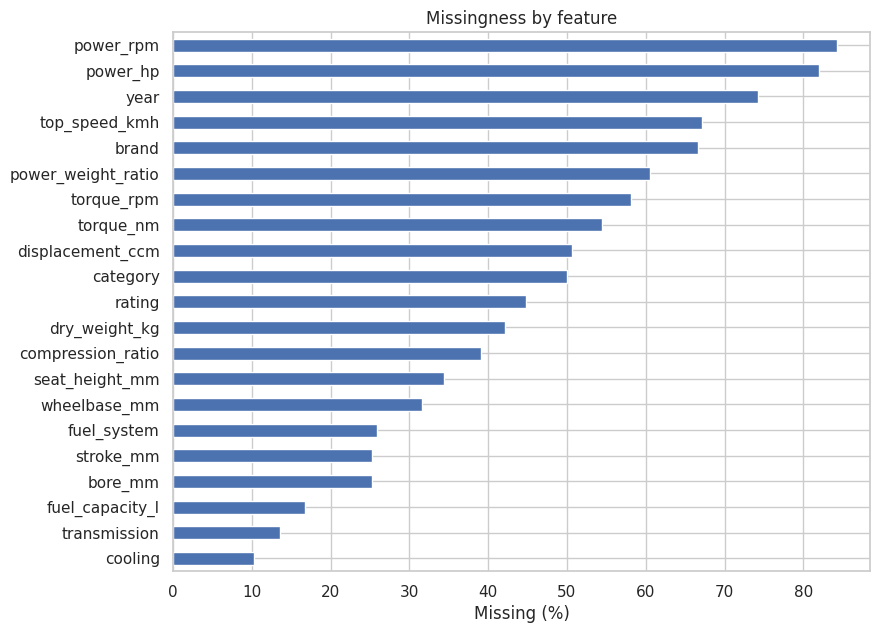

,missing_%
power_rpm,84.29
power_hp,82.01
year,74.20
top_speed_kmh,67.17
brand,66.62
power_weight_ratio,60.53
torque_rpm,58.13
torque_nm,54.43


In [5]:
# ----- 1.4 缺失值報告：算出每個欄位的缺失百分比，並畫成長條圖 -----
miss = (df.isna().mean() * 100).round(2).sort_values()  # 每欄缺失比例(%)，由小到大排序
ax = miss.plot.barh(figsize=(9, 7), color="#4C72B0")    # 水平長條圖
ax.set_xlabel("Missing (%)")
ax.set_title("Missingness by feature")
plt.show()
# 順便印出缺失最嚴重的前 8 個欄位
miss.sort_values(ascending=False).to_frame("missing_%").head(8)

In [6]:
# ----- 1.5 驗證解析「正確性」：把原始字串 vs 解析出的數字並排印出來 -----
# 挑出 Power / Top speed / Bore x stroke 都有值的前 4 列
idx = raw.index[raw["Power"].notna() & raw["Top speed"].notna() & raw["Bore x stroke"].notna()][:4]
for i in idx:
    print(f"Power     原始={raw.loc[i,'Power']!r:38s} -> 馬力={df.loc[i,'power_hp']}, 轉速={df.loc[i,'power_rpm']}")
    print(f"Top speed 原始={raw.loc[i,'Top speed']!r:38s} -> 極速={df.loc[i,'top_speed_kmh']}")
    print(f"Bore×str  原始={raw.loc[i,'Bore x stroke']!r:38s} -> 缸徑={df.loc[i,'bore_mm']}, 行程={df.loc[i,'stroke_mm']}\n")
# 重點：某筆資料行程寫成不可能的 552mm(鍵入錯誤)，會被合理範圍檢查正確地剔除成 NaN
print("可見每個數字都解析正確；不合理的 552mm 行程則被自動剔除為 NaN。")

Power     原始='91.0 HP (66.4 kW)) @ 4750 RPM'        -> 馬力=91.0, 轉速=4750.0
Top speed 原始='178.6 km/h (111.0 mph)'               -> 極速=178.6
Bore×str  原始='107.1 x 100.0 mm (4.2 x 3.9 inches)'  -> 缸徑=107.1, 行程=100.0

Power     原始='100.0 HP (73.0 kW)) @ 10500 RPM'      -> 馬力=100.0, 轉速=10500.0
Top speed 原始='235.0 km/h (146.0 mph)'               -> 極速=235.0
Bore×str  原始='81.0 x 63.9 mm (3.2 x 2.5 inches)'    -> 缸徑=81.0, 行程=63.9

Power     原始='170.0 HP (124.1 kW)) @ 11000 RPM'     -> 馬力=170.0, 轉速=11000.0
Top speed 原始='193.1 km/h (120.0 mph)'               -> 極速=193.1
Bore×str  原始='80.0 x 49.7 mm (3.1 x 2.0 inches)'    -> 缸徑=80.0, 行程=49.7

Power     原始='105.0 HP (76.6 kW)) @ 10500 RPM'      -> 馬力=105.0, 轉速=10500.0
Top speed 原始='235.0 km/h (146.0 mph)'               -> 極速=235.0
Bore×str  原始='81.0 x 63.9 mm (3.2 x 2.5 inches)'    -> 缸徑=81.0, 行程=63.9

可見每個數字都解析正確；不合理的 552mm 行程則被自動剔除為 NaN。


In [7]:
# ----- 1.6 清理後數值的描述統計 + 建立「建模子集」 -----
display(df[NUMERIC_COLS].describe().T.round(2))   # 每個數值欄位的：筆數/平均/標準差/最小/四分位/最大

# 建模特徵(挑資訊量高的 13 個數值規格)
MODEL_FEATURES = ["displacement_ccm","power_hp","torque_nm","top_speed_kmh","dry_weight_kg",
                  "fuel_capacity_l","seat_height_mm","wheelbase_mm","bore_mm","stroke_mm",
                  "compression_ratio","power_weight_ratio","power_rpm"]
top_cats = df["category"].value_counts().head(TOP_N).index.tolist()   # 數量最多的前 8 車種
core = ["displacement_ccm","dry_weight_kg"]                           # 這兩個核心規格一定要有值
# 篩選：屬於前 8 車種 且 核心規格不缺，當作後續分類/分群的資料
model_df = df[df["category"].isin(top_cats) & df[core].notna().all(axis=1)].copy().reset_index(drop=True)
print("前 8 大車種:", top_cats)
print("建模子集維度:", model_df.shape)            # 約 9842 列 × 21 欄

,count,mean,std,min,25%,50%,75%,max
displacement_ccm,21002.0,537.25,475.93,25.0,125.00,395.00,799.00,2575.0
power_hp,7659.0,50.01,48.74,1.0,12.20,30.00,75.00,357.0
torque_nm,19396.0,63.21,57.87,1.5,12.20,55.60,101.00,600.0
top_speed_kmh,13973.0,137.43,58.28,20.0,95.00,130.00,176.00,439.4
dry_weight_kg,24630.0,163.57,83.72,20.0,105.00,145.00,199.00,700.0
fuel_capacity_l,35429.0,13.16,5.99,1.0,8.00,13.00,17.03,54.0
seat_height_mm,27909.0,791.23,85.58,400.0,750.00,790.00,833.00,998.0
wheelbase_mm,29117.0,1420.66,163.52,725.0,1325.00,1422.00,1499.00,2184.0
power_weight_ratio,16801.0,0.27,0.26,0.0,0.09,0.16,0.39,2.3
power_rpm,6687.0,7752.28,1882.36,510.0,6500.00,7500.00,8900.00,15500.0


前 8 大車種: ['Scooter', 'Sport', 'Enduro / offroad', 'Custom / cruiser', 'Naked bike', 'Allround', 'Classic', 'Super motard']
建模子集維度: (9842, 21)


## 2. 探索式資料分析 (EDA) — *對應指示 #2*

用統計摘要與視覺化先建立對資料的直覺：分布形狀、變數間相關、車種差異、隨年代的趨勢。

In [8]:
# ----- 2.1 數值摘要(加上偏態 skew) -----
summ = df[NUMERIC_COLS].describe().T              # 基本描述統計
summ["skew"] = df[NUMERIC_COLS].skew(numeric_only=True)  # skew=偏態：>0 代表右偏(長尾在右)
summ.round(2)
# 觀察：多數規格右偏，所以後面統計檢定會搭配「取對數」與「無母數方法」

,count,mean,std,min,25%,50%,75%,max,skew
displacement_ccm,21002.0,537.25,475.93,25.0,125.00,395.00,799.00,2575.0,1.11
power_hp,7659.0,50.01,48.74,1.0,12.20,30.00,75.00,357.0,1.51
torque_nm,19396.0,63.21,57.87,1.5,12.20,55.60,101.00,600.0,2.31
top_speed_kmh,13973.0,137.43,58.28,20.0,95.00,130.00,176.00,439.4,0.55
dry_weight_kg,24630.0,163.57,83.72,20.0,105.00,145.00,199.00,700.0,1.57
fuel_capacity_l,35429.0,13.16,5.99,1.0,8.00,13.00,17.03,54.0,0.42
seat_height_mm,27909.0,791.23,85.58,400.0,750.00,790.00,833.00,998.0,-0.22
wheelbase_mm,29117.0,1420.66,163.52,725.0,1325.00,1422.00,1499.00,2184.0,0.10
power_weight_ratio,16801.0,0.27,0.26,0.0,0.09,0.16,0.39,2.3,1.67
power_rpm,6687.0,7752.28,1882.36,510.0,6500.00,7500.00,8900.00,15500.0,0.39


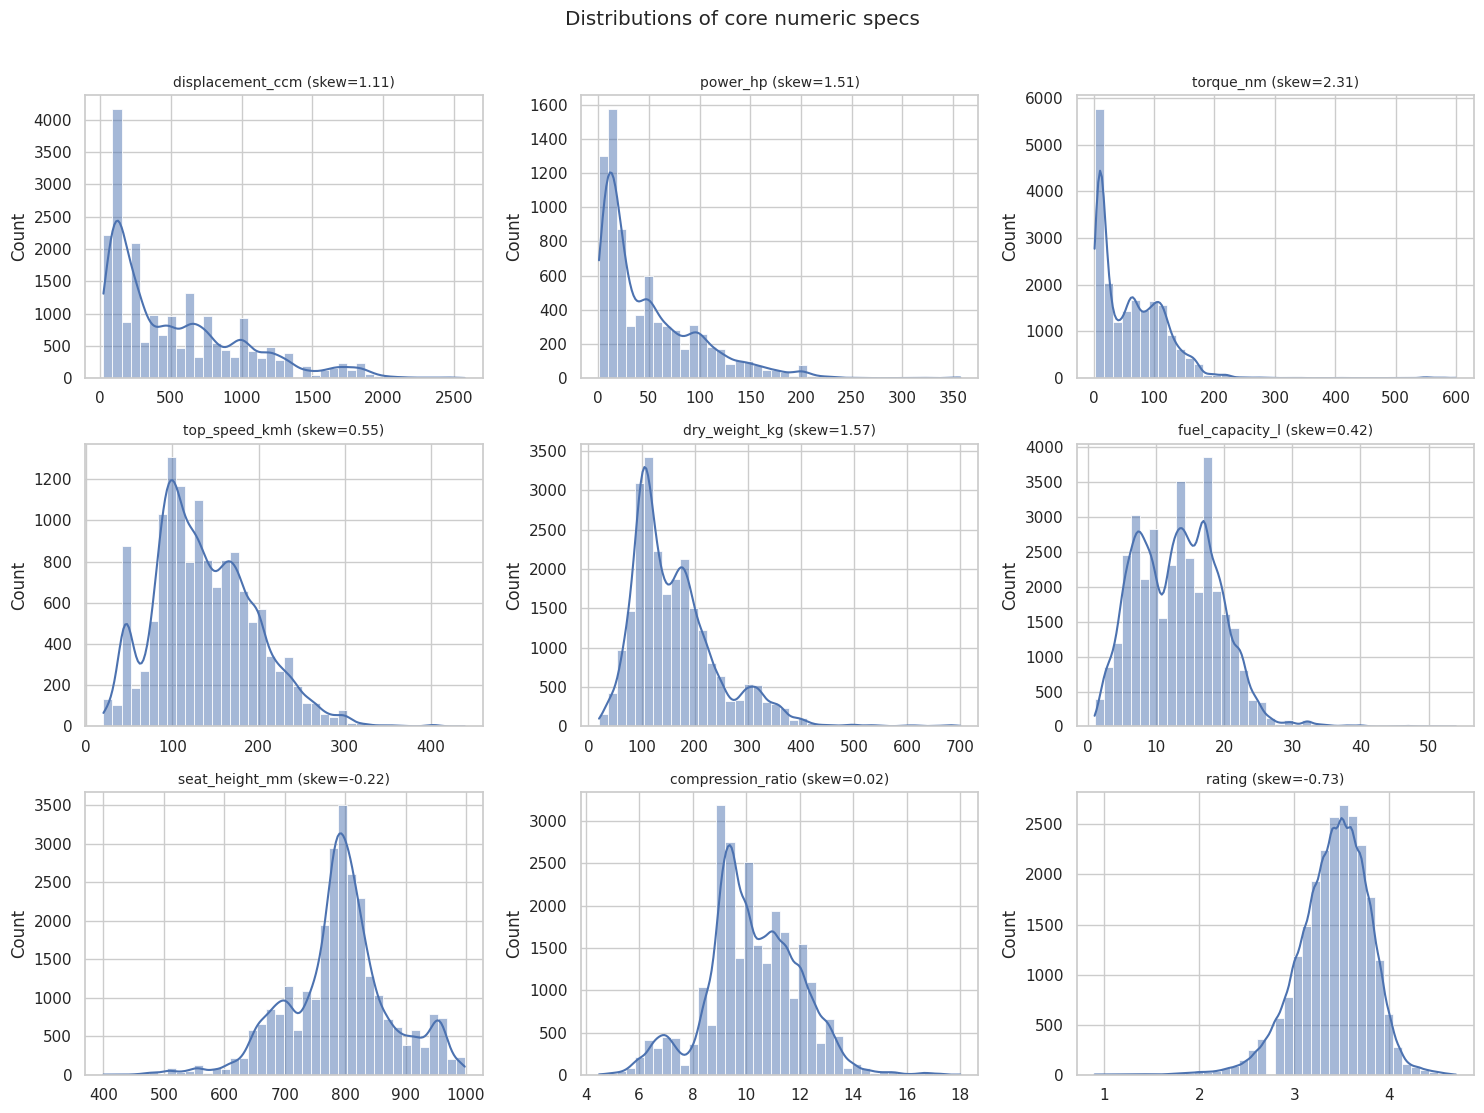

In [9]:
# ----- 2.2 核心規格的分布圖(直方圖 + 密度曲線) -----
cols = ["displacement_ccm","power_hp","torque_nm","top_speed_kmh","dry_weight_kg",
        "fuel_capacity_l","seat_height_mm","compression_ratio","rating"]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))  # 3x3 的子圖
for ax, c in zip(axes.ravel(), cols):
    d = df[c].dropna()                            # 去掉缺失值再畫
    sns.histplot(d, bins=40, kde=True, ax=ax, color="#4C72B0")  # kde=True 疊上平滑密度曲線
    ax.set_title(f"{c} (skew={d.skew():.2f})", fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Distributions of core numeric specs", y=1.01)
fig.tight_layout()
plt.show()

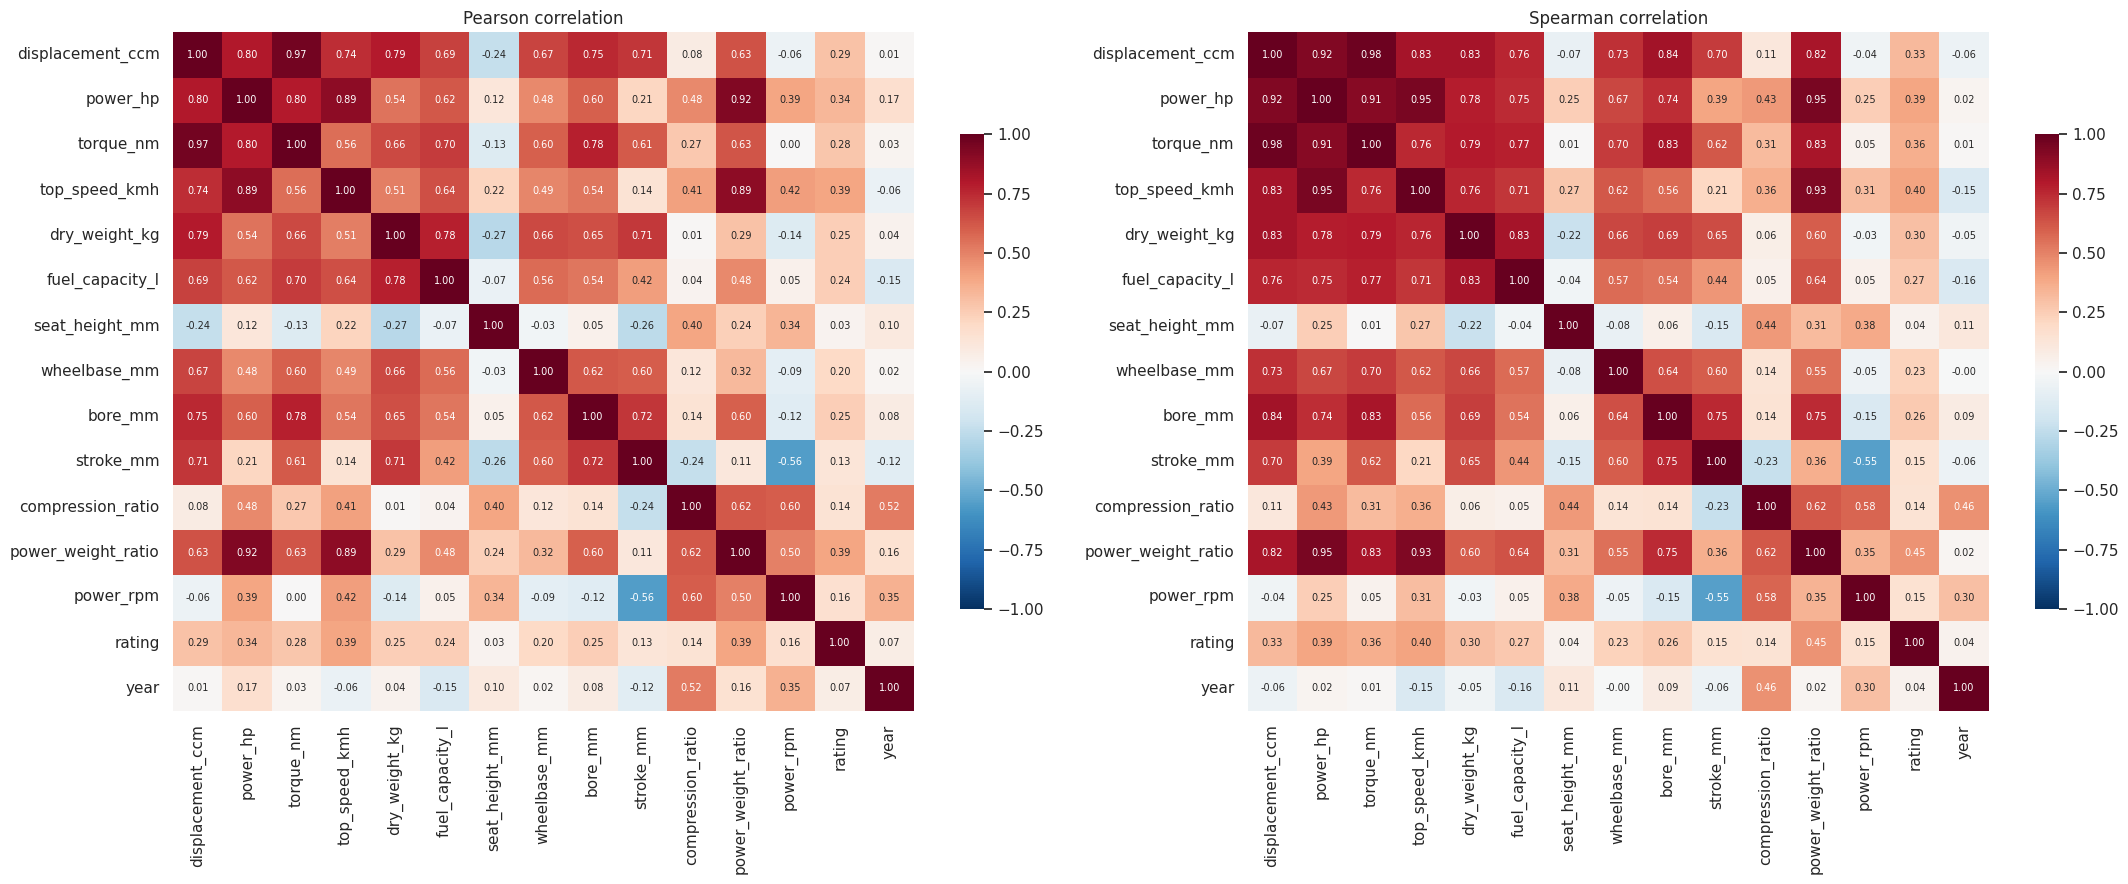

In [10]:
# ----- 2.3 相關係數熱圖(Pearson 線性 vs Spearman 單調) -----
ccols = ["displacement_ccm","power_hp","torque_nm","top_speed_kmh","dry_weight_kg",
         "fuel_capacity_l","seat_height_mm","wheelbase_mm","bore_mm","stroke_mm",
         "compression_ratio","power_weight_ratio","power_rpm","rating","year"]
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = df[ccols].corr(method=method)          # 計算相關矩陣
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=ax, annot_kws={"size": 7}, cbar_kws={"shrink": .7})  # 紅=正相關, 藍=負相關
    ax.set_title(f"{method.title()} correlation")
fig.tight_layout()
plt.show()
# 觀察：排氣量~扭力、馬力~極速幾乎完全正相關；Pearson 與 Spearman 差距代表「非線性但單調」的關係

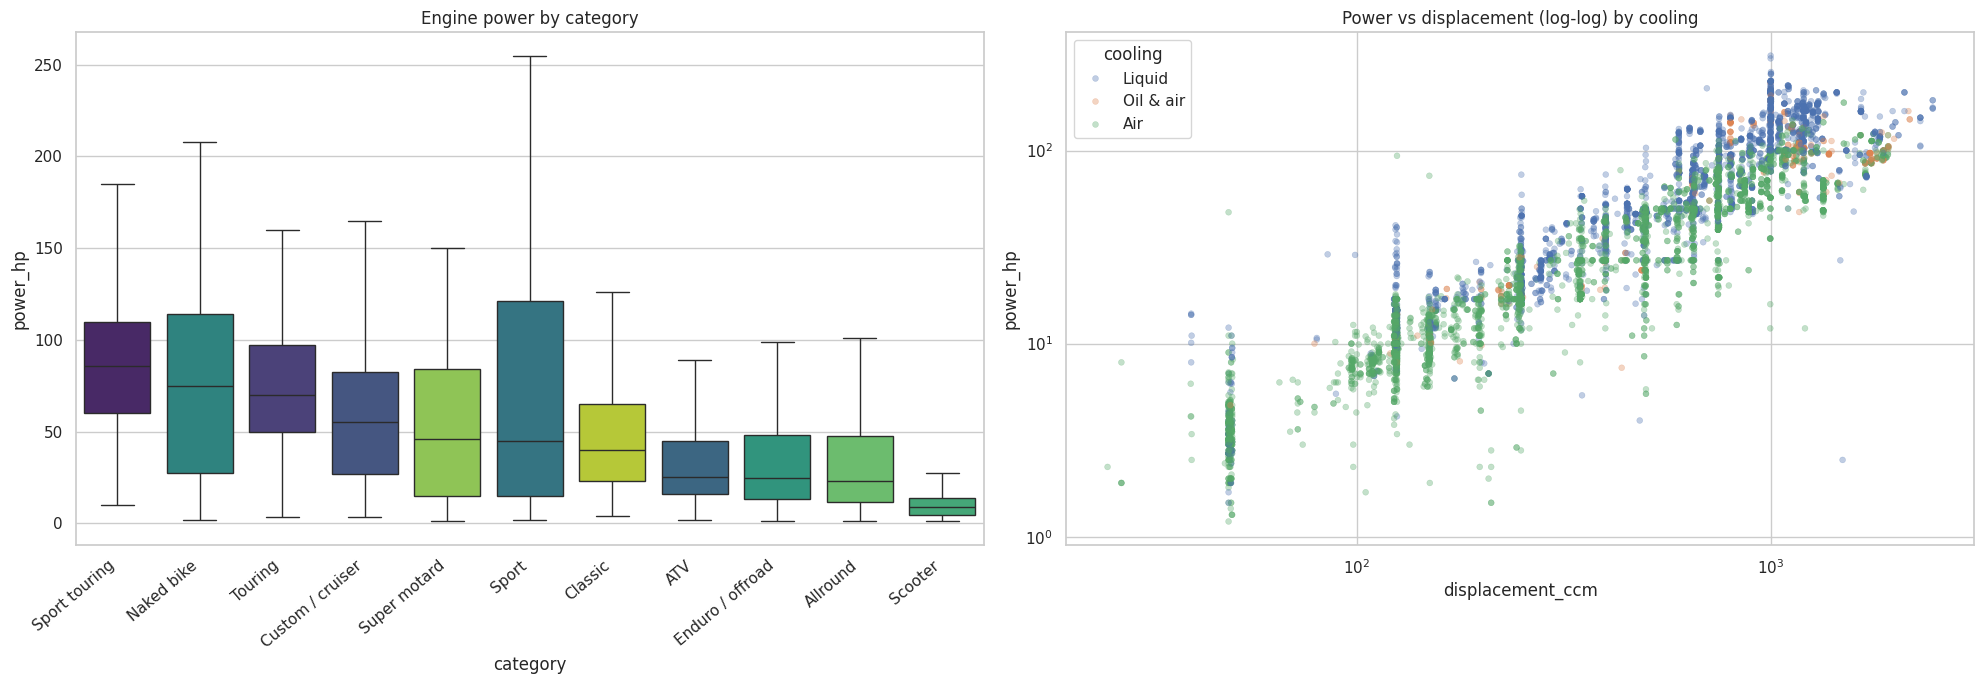

In [11]:
# ----- 2.4 馬力 vs 車種(箱型圖) 與 排氣量 vs 馬力(雙對數散布圖) -----
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 左圖：各車種的馬力分布(只看數量>=100 的車種)，依中位數由大到小排
s = df.dropna(subset=["power_hp","category"])
order = s.groupby("category")["power_hp"].median().sort_values(ascending=False).index
order = [c for c in order if s["category"].value_counts()[c] >= 100]
sns.boxplot(data=s[s.category.isin(order)], x="category", y="power_hp", order=order,
            showfliers=False, ax=axes[0], hue="category", palette="viridis", legend=False)
axes[0].set_title("Engine power by category")
axes[0].tick_params(axis="x", rotation=40)
for l in axes[0].get_xticklabels():
    l.set_ha("right")

# 右圖：排氣量 vs 馬力，用對數座標(因為兩者呈冪次關係)，並用冷卻方式上色
s2 = df.dropna(subset=["displacement_ccm","power_hp","cooling"])
s2 = s2[s2.cooling.isin(["Air","Liquid","Oil & air"])]
sns.scatterplot(data=s2, x="displacement_ccm", y="power_hp", hue="cooling",
                alpha=.35, s=18, ax=axes[1], edgecolor=None)
axes[1].set_xscale("log"); axes[1].set_yscale("log")   # 雙對數座標
axes[1].set_title("Power vs displacement (log-log) by cooling")
fig.tight_layout()
plt.show()

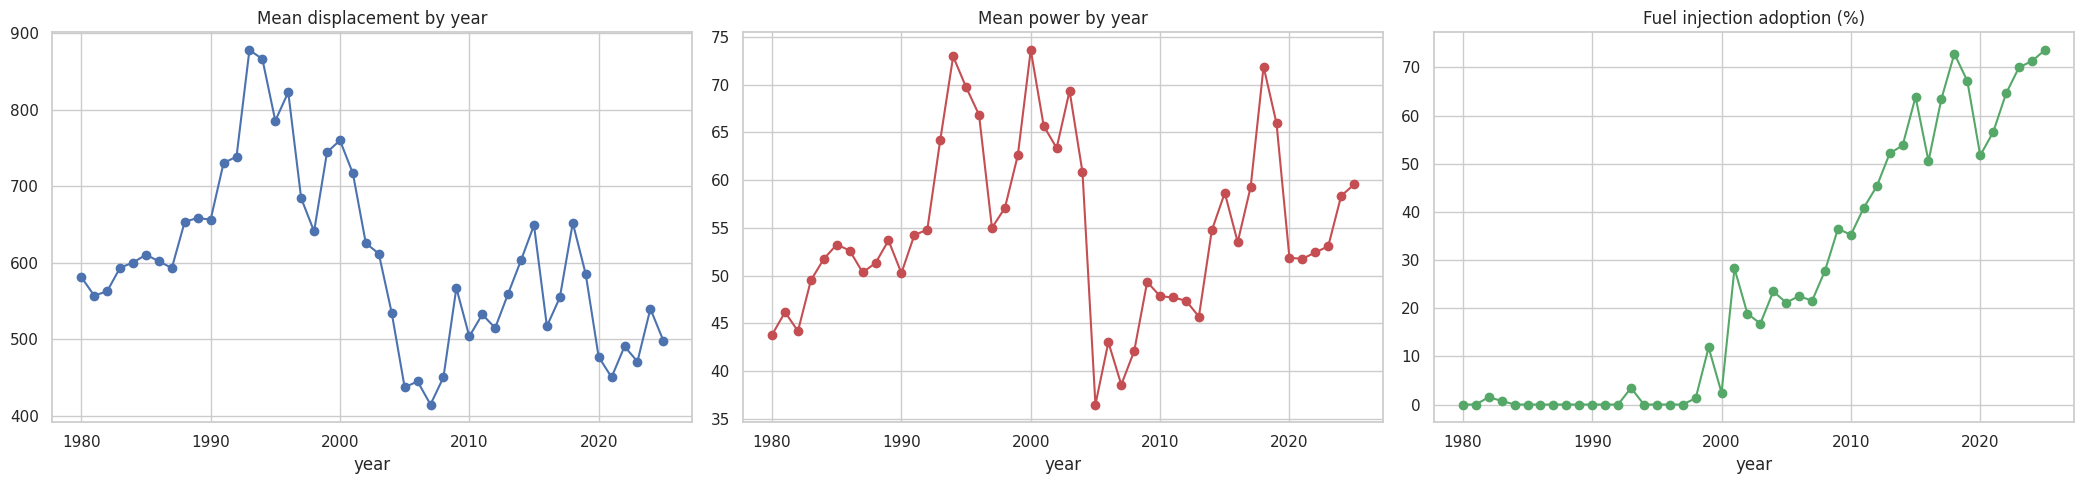

In [12]:
# ----- 2.5 技術隨「年代」的演變(1980 年以後) -----
s = df.dropna(subset=["year"])
s = s[s.year >= 1980]
g = s.groupby(s.year.astype(int))                 # 依年份分組
fig, ax = plt.subplots(1, 3, figsize=(21, 5))
g["displacement_ccm"].mean().plot(ax=ax[0], marker="o", color="#4C72B0")
ax[0].set_title("Mean displacement by year")
g["power_hp"].mean().plot(ax=ax[1], marker="o", color="#C44E52")
ax[1].set_title("Mean power by year")
(g["fuel_system"].apply(lambda x: (x == "Injection").mean()) * 100).plot(ax=ax[2], marker="o", color="#55A868")
ax[2].set_title("Fuel injection adoption (%)")          # 觀察：噴射逐漸取代化油器
fig.tight_layout()
plt.show()

## 3. 統計方法 (Statistical Methods) — *對應指示 #3*

每個檢定都會：寫出虛無假設 H₀、報告統計量 + p 值 + **效應量**，並讓「有母數」與「無母數」方法互相佐證，
這樣結論就不會只依賴常態性假設。

In [13]:
# ----- 3.A 常態性檢定(D'Agostino-Pearson K^2) -----
# H0: 該變數服從常態分布。p<0.05 就拒絕(代表不常態)
from scipy import stats
rows = []
for c in ["power_hp","displacement_ccm","top_speed_kmh","dry_weight_kg"]:
    x  = df[c].dropna()
    xs = x.sample(min(5000, len(x)), random_state=RANDOM_STATE)  # 抽樣 5000 筆檢定(避免樣本過大過度敏感)
    _, p  = stats.normaltest(xs)                  # 原始尺度的常態性
    _, pl = stats.normaltest(np.log(xs[xs > 0]))  # 取對數後的常態性
    rows.append([c, round(x.skew(), 2), f"{p:.1e}", round(np.log(x[x > 0]).skew(), 2), f"{pl:.1e}"])
pd.DataFrame(rows, columns=["變數","偏態","p值(原始)","偏態(取log)","p值(取log)"])
# 結論：原始規格都不常態(右偏)，取對數後偏態接近 0 -> 後續對數尺度用有母數、原始尺度用無母數

,變數,偏態,p值(原始),偏態(取log),p值(取log)
0,power_hp,1.51,1.2e-310,-0.33,3.9e-61
1,displacement_ccm,1.11,3.6e-159,-0.26,1.9e-281
2,top_speed_kmh,0.55,1.8e-33,-0.74,2.9e-100
3,dry_weight_kg,1.57,0.0e+00,-0.12,5.1e-05


水冷 n=2807 平均=74.9HP | 氣冷 n=3826 平均=30.2HP
Welch t=37.6 (p=2.44e-263) | Mann-Whitney p=1.65e-293 | Cohen's d=1.03(大效應)


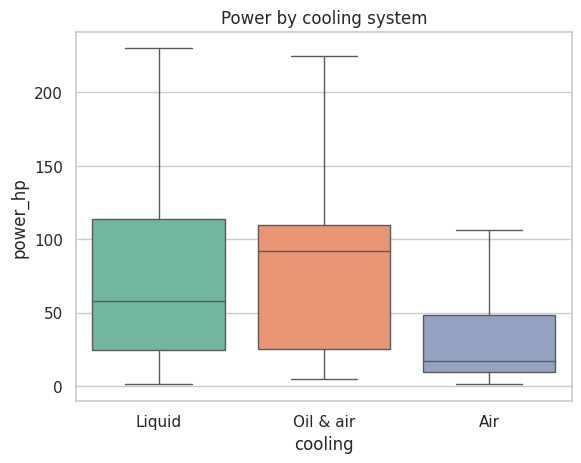

In [14]:
# ----- 3.B 雙組檢定：水冷 vs 氣冷 引擎的馬力是否不同 -----
# H0: 兩組平均馬力相等
sub = df.dropna(subset=["power_hp","cooling"])
liq = sub.loc[sub.cooling == "Liquid", "power_hp"]   # 水冷組
air = sub.loc[sub.cooling == "Air",    "power_hp"]    # 氣冷組
t, p   = stats.ttest_ind(liq, air, equal_var=False)              # Welch t 檢定(不假設等變異)
u, pu  = stats.mannwhitneyu(liq, air, alternative="two-sided")   # Mann-Whitney U(無母數，較穩健)
# Cohen's d 效應量(差異有多大；0.8 以上算大)
sp = np.sqrt(((len(liq)-1)*liq.std(ddof=1)**2 + (len(air)-1)*air.std(ddof=1)**2) / (len(liq)+len(air)-2))
d  = (liq.mean() - air.mean()) / sp
print(f"水冷 n={len(liq)} 平均={liq.mean():.1f}HP | 氣冷 n={len(air)} 平均={air.mean():.1f}HP")
print(f"Welch t={t:.1f} (p={p:.2e}) | Mann-Whitney p={pu:.2e} | Cohen's d={d:.2f}(大效應)")
# 畫箱型圖佐證
sns.boxplot(data=sub[sub.cooling.isin(['Air','Liquid','Oil & air'])], x="cooling", y="power_hp",
            showfliers=False, hue="cooling", palette="Set2", legend=False)
plt.title("Power by cooling system")
plt.show()

In [15]:
# ----- 3.C 多組檢定：不同車種的馬力是否不同(ANOVA + Kruskal + Tukey 事後比較) -----
from statsmodels.stats.multicomp import pairwise_tukeyhsd
s = df.dropna(subset=["power_hp","category"]).copy()
keep = s.category.value_counts()
keep = keep[keep >= 100].index                   # 只比數量>=100 的車種
s = s[s.category.isin(keep)].copy()
s["lp"] = np.log(s.power_hp)                      # 取對數讓分布較常態
groups = [g.power_hp.values for _, g in s.groupby("category")]

F, pf = stats.f_oneway(*[np.log(g) for g in groups])  # 單因子 ANOVA(對數尺度)
H, ph = stats.kruskal(*groups)                        # Kruskal-Wallis(無母數)
# eta^2 效應量：車種能解釋多少比例的馬力變異
grand = s.lp.mean()
ssb = sum(len(g) * (np.log(g).mean() - grand)**2 for g in groups)  # 組間平方和
eta2 = ssb / ((s.lp - grand)**2).sum()
print(f"ANOVA F={F:.1f}(p={pf:.1e}) | Kruskal H={H:.0f}(p={ph:.1e}) | eta^2={eta2:.3f}")

# Tukey HSD：兩兩車種比較，看哪些配對有顯著差異
tuk = pairwise_tukeyhsd(s.lp, s.category, alpha=ALPHA)
td = pd.DataFrame(tuk.summary().data[1:], columns=tuk.summary().data[0])
print("Tukey 事後比較：%d/%d 個車種配對有顯著差異" % (td.reject.astype(str).eq('True').sum(), len(td)))
td.head(8)                                        # 顯示前 8 個配對

ANOVA F=421.6(p=0.0e+00) | Kruskal H=2597(p=0.0e+00) | eta^2=0.371


Tukey 事後比較：48/55 個車種配對有顯著差異


,group1,group2,meandiff,p-adj,lower,upper,reject
0,ATV,Allround,0.0067,1.0,-0.2565,0.2698,False
1,ATV,Classic,0.4457,0.0,0.1778,0.7137,True
2,ATV,Custom / cruiser,0.6821,0.0,0.4160,0.9482,True
3,ATV,Enduro / offroad,0.0484,1.0,-0.2169,0.3137,False
4,ATV,Naked bike,0.8779,0.0,0.6173,1.1385,True
5,ATV,Scooter,-1.0116,0.0,-1.2641,-0.7591,True
6,ATV,Sport,0.5651,0.0,0.3119,0.8182,True
7,ATV,Sport touring,1.1959,0.0,0.9159,1.4759,True


In [16]:
# ----- 3.D 相關性檢定(Pearson 與 Spearman，附樣本數) -----
pairs = [("displacement_ccm","power_hp"),     # 排氣量 vs 馬力
         ("power_hp","top_speed_kmh"),        # 馬力 vs 極速
         ("dry_weight_kg","top_speed_kmh"),   # 乾重 vs 極速
         ("displacement_ccm","torque_nm"),    # 排氣量 vs 扭力
         ("compression_ratio","power_weight_ratio")]  # 壓縮比 vs 馬力重量比
out = []
for a, b in pairs:
    z = df[[a, b]].dropna()                    # 兩欄都有值才算
    r, _   = stats.pearsonr(z[a], z[b])        # Pearson(線性相關)
    rho, _ = stats.spearmanr(z[a], z[b])       # Spearman(單調相關)
    out.append([f"{a} ~ {b}", len(z), round(r, 3), round(rho, 3)])
pd.DataFrame(out, columns=["變數配對","n","Pearson r","Spearman rho"])

,變數配對,n,Pearson r,Spearman rho
0,displacement_ccm ~ power_hp,7393,0.804,0.924
1,power_hp ~ top_speed_kmh,3583,0.893,0.948
2,dry_weight_kg ~ top_speed_kmh,7007,0.509,0.762
3,displacement_ccm ~ torque_nm,9365,0.968,0.978
4,compression_ratio ~ power_weight_ratio,9086,0.618,0.618


In [17]:
# ----- 3.E 卡方獨立性檢定：冷卻方式 與 傳動方式 是否獨立 -----
# H0: 兩個類別變數互相獨立(無關聯)
s = df.dropna(subset=["cooling","transmission"])
s = s[s.cooling.isin(['Air','Liquid','Oil & air'])]
ct = pd.crosstab(s.cooling, s.transmission)    # 列聯表(交叉次數)
chi2, p, dof, _ = stats.chi2_contingency(ct)   # 卡方檢定
# Cramer's V 效應量(關聯強度，0~1；0.1=弱)
n = ct.values.sum(); r, k = ct.shape
phi2 = max(0, chi2/n - (k-1)*(r-1)/(n-1))
V = np.sqrt(phi2 / min(k-1, r-1))
print(f"chi2={chi2:.1f}, 自由度={dof}, p={p:.2e} | Cramer's V={V:.3f}(顯著但關聯很弱)")
print("教學重點：樣本很大時，p 值會很顯著，但效應量(V)才告訴你關聯實際上有多強。")
ct                                             # 顯示列聯表

chi2=682.1, 自由度=4, p=2.67e-146 | Cramer's V=0.100(顯著但關聯很弱)
教學重點：樣本很大時，p 值會很顯著，但效應量(V)才告訴你關聯實際上有多強。


transmission,Belt,Chain,Shaft
cooling,,,
Air,4310,9555,1869
Liquid,2702,11752,2159
Oil & air,399,921,323


模型A  log(極速)~log(馬力)+log(乾重): n=1648, R2=0.893
  log(馬力)係數=0.427  (理論值約 0.33，資料印證了物理關係!)
模型B  多變數: n=1081, R2=0.864, F=1134
VIF(共線性檢查): {'power_hp': np.float64(3.48), 'dry_weight_kg': np.float64(3.3), 'displacement_ccm': np.float64(4.98), 'fuel_capacity_l': np.float64(2.98)}


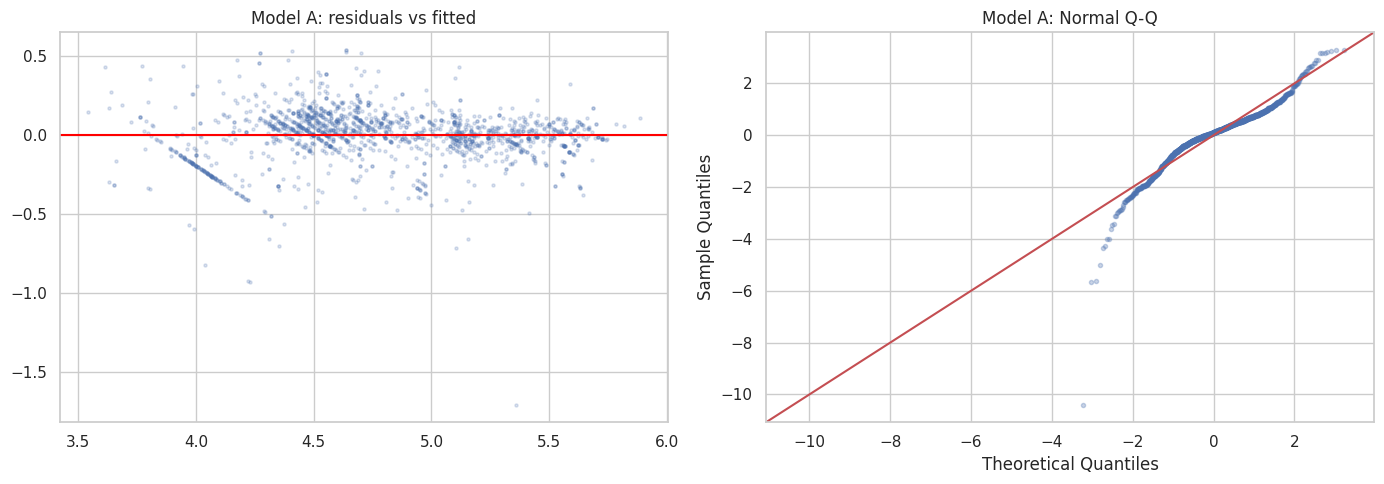

In [18]:
# ----- 3.F 迴歸分析：兩個模型 + 共線性(VIF) + 殘差診斷圖 -----
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 模型 A(物理動機，雙對數)：log(極速) ~ log(馬力) + log(乾重)
# 空氣阻力理論：受阻力限制的極速約正比於 馬力^(1/3)，所以 log(馬力)的係數理論上應接近 0.33
a = df.dropna(subset=["top_speed_kmh","power_hp","dry_weight_kg"]).copy()
a = a[(a.power_hp > 0) & (a.dry_weight_kg > 0) & (a.top_speed_kmh > 0)]
a["ltop"] = np.log(a.top_speed_kmh)
a["lpow"] = np.log(a.power_hp)
a["lwt"]  = np.log(a.dry_weight_kg)
mA = smf.ols("ltop ~ lpow + lwt", data=a).fit()      # OLS 最小平方法
print(f"模型A  log(極速)~log(馬力)+log(乾重): n={int(mA.nobs)}, R2={mA.rsquared:.3f}")
print(f"  log(馬力)係數={mA.params['lpow']:.3f}  (理論值約 0.33，資料印證了物理關係!)")

# 模型 B(多變數)：極速 ~ 馬力 + 乾重 + 排氣量 + 油箱 + 冷卻方式(類別)
b = df.dropna(subset=["top_speed_kmh","power_hp","dry_weight_kg","displacement_ccm",
                      "fuel_capacity_l","cooling"]).copy()
b = b[b.cooling.isin(['Air','Liquid','Oil & air'])]
b["cooling"] = b.cooling.astype("category")          # 字串轉類別，公式會自動建虛擬變數
mB = smf.ols("top_speed_kmh ~ power_hp + dry_weight_kg + displacement_ccm + fuel_capacity_l + cooling",
             data=b).fit()
print(f"模型B  多變數: n={int(mB.nobs)}, R2={mB.rsquared:.3f}, F={mB.fvalue:.0f}")

# VIF 變異數膨脹因子：檢查自變數間是否「共線性」太高(經驗上 <5 沒問題)
Xc = ["power_hp","dry_weight_kg","displacement_ccm","fuel_capacity_l"]
X = sm.add_constant(b[Xc])
print("VIF(共線性檢查):", {c: round(variance_inflation_factor(X.values, i+1), 2) for i, c in enumerate(Xc)})

# 殘差診斷：左=殘差 vs 預測值(看是否隨機分散)，右=殘差 Q-Q 圖(看是否近常態)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(mA.fittedvalues, mA.resid, s=5, alpha=.2)
ax[0].axhline(0, color="red")
ax[0].set_title("Model A: residuals vs fitted")
sm.qqplot(mA.resid, line="45", fit=True, ax=ax[1], markersize=3, alpha=.3)
ax[1].set_title("Model A: Normal Q-Q")
fig.tight_layout()
plt.show()

## 4. 資料採礦 (Data Mining) — *對應指示 #4*

在 9,842 台機車的建模子集上，套用三大類經典技術：**分類、分群、關聯規則**。

In [19]:
# ----- 4.1 分類：用規格預測「車種」(用 Pipeline 防止資料洩漏，5 折交叉驗證) -----
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer              # 補缺失值
from sklearn.preprocessing import StandardScaler      # 標準化
from sklearn.linear_model import LogisticRegression   # 邏輯迴歸(線性模型)
from sklearn.ensemble import RandomForestClassifier   # 隨機森林(非線性、可抓交互作用)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

X, y = model_df[MODEL_FEATURES], model_df["category"]  # X=特徵, y=目標(車種)
# 切分訓練/測試集；stratify=y 確保各車種比例一致
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

# 兩個模型都包成 Pipeline：補值 -> (標準化) -> 分類器
# 關鍵：補值/標準化放在 Pipeline 內，交叉驗證時只用訓練折學習，避免測試資料外洩
models = {
 "邏輯迴歸": Pipeline([("imp", SimpleImputer(strategy="median")),
                       ("sc",  StandardScaler()),
                       ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
 "隨機森林": Pipeline([("imp", SimpleImputer(strategy="median")),
                       ("clf", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1))]),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)   # 5 折分層交叉驗證
fitted = {}
for name, pipe in models.items():
    f1cv = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="f1_macro", n_jobs=-1)  # 交叉驗證 macro-F1
    pipe.fit(Xtr, ytr)                            # 用全部訓練資料再訓練一次
    pred = pipe.predict(Xte)                       # 對測試集預測
    fitted[name] = (pipe, pred)
    print(f"{name}  交叉驗證F1={f1cv.mean():.3f}±{f1cv.std():.3f} | "
          f"測試準確率={accuracy_score(yte, pred):.3f} | macro-F1={f1_score(yte, pred, average='macro'):.3f}")
# 隨機森林明顯較佳 -> 代表規格與車種的關係是「非線性」的
best = "隨機森林"; pipe, pred = fitted[best]
print("\n各車種詳細表現(precision/recall/f1):\n", classification_report(yte, pred, zero_division=0))

邏輯迴歸  交叉驗證F1=0.432±0.018 | 測試準確率=0.570 | macro-F1=0.438


隨機森林  交叉驗證F1=0.751±0.011 | 測試準確率=0.798 | macro-F1=0.761

各車種詳細表現(precision/recall/f1):
                   precision    recall  f1-score   support

        Allround       0.74      0.65      0.69       250
         Classic       0.80      0.61      0.69        90
Custom / cruiser       0.89      0.91      0.90       348
Enduro / offroad       0.80      0.80      0.80       375
      Naked bike       0.74      0.76      0.75       279
         Scooter       0.88      0.95      0.91       575
           Sport       0.70      0.73      0.71       409
    Super motard       0.71      0.59      0.64       135

        accuracy                           0.80      2461
       macro avg       0.78      0.75      0.76      2461
    weighted avg       0.80      0.80      0.80      2461



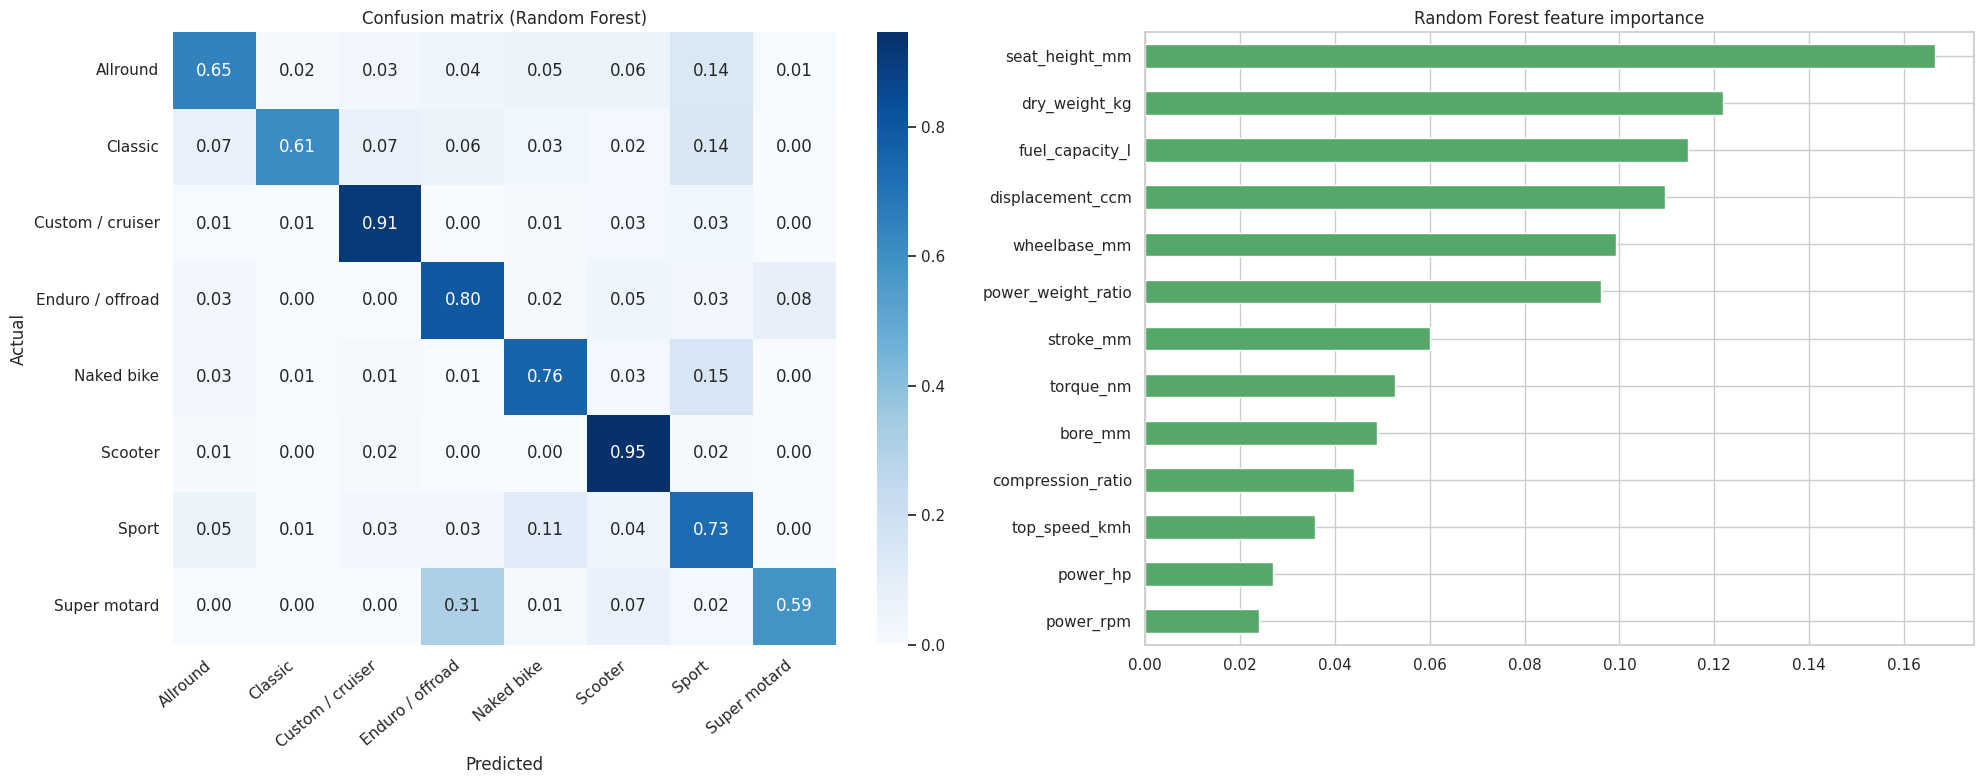

In [20]:
# ----- 4.2 混淆矩陣 + 隨機森林特徵重要度 -----
labels = sorted(y.unique())
# 混淆矩陣(列正規化)：對角線=判對比例，非對角線=被判成其他車種的比例
cm = confusion_matrix(yte, pred, labels=labels, normalize="true")
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title("Confusion matrix (Random Forest)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
plt.setp(ax[0].get_xticklabels(), rotation=40, ha="right")
# 特徵重要度：哪些規格對「判斷車種」最有用
rf = fitted["隨機森林"][0].named_steps["clf"]
pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values().plot.barh(ax=ax[1], color="#55A868")
ax[1].set_title("Random Forest feature importance")
fig.tight_layout()
plt.show()
# 觀察：座高、乾重、油箱、排氣量最有區別力(巡航車座低車重、越野車座高車輕)

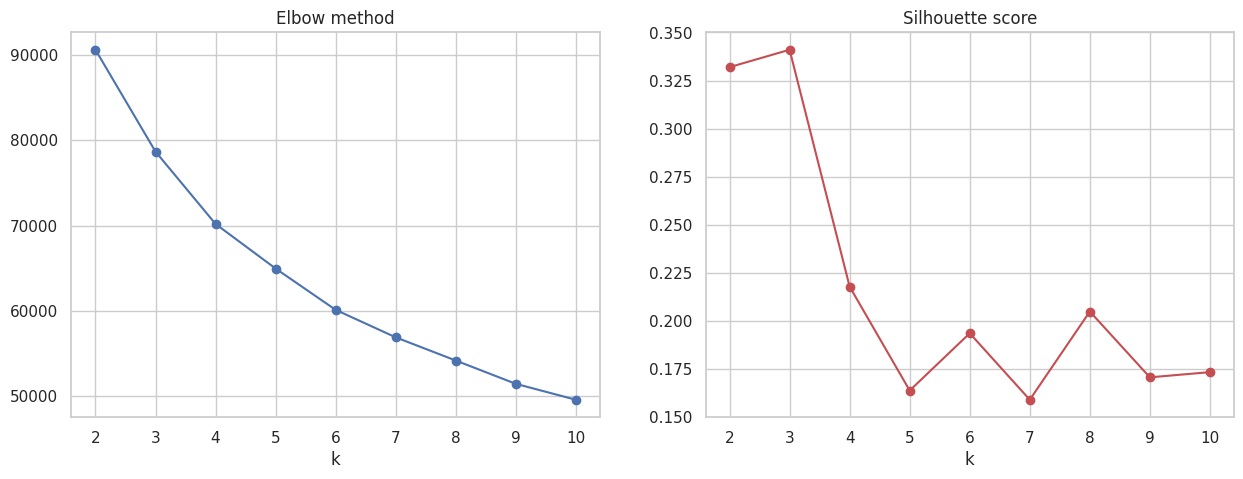

選定的群數 k = 3


In [21]:
# ----- 4.3 分群：用「手肘法」與「輪廓係數」決定分幾群(k) -----
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# 先補值再標準化(分群是非監督式，全域處理可接受)
Xc = model_df[MODEL_FEATURES].fillna(model_df[MODEL_FEATURES].median(numeric_only=True))
Xs = StandardScaler().fit_transform(Xc)           # 標準化(各特徵平均0、標準差1)
ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(Xs)
    inertia.append(km.inertia_)                                   # inertia=群內平方和(越小越緊密)
    sil.append(silhouette_score(Xs, km.labels_, sample_size=4000, random_state=RANDOM_STATE))  # 輪廓係數(越大越好)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set_title("Elbow method"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sil, "o-", color="#C44E52"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.show()
best_k = list(ks)[int(np.argmax(sil))]            # 取輪廓係數最大的 k
print("選定的群數 k =", best_k)

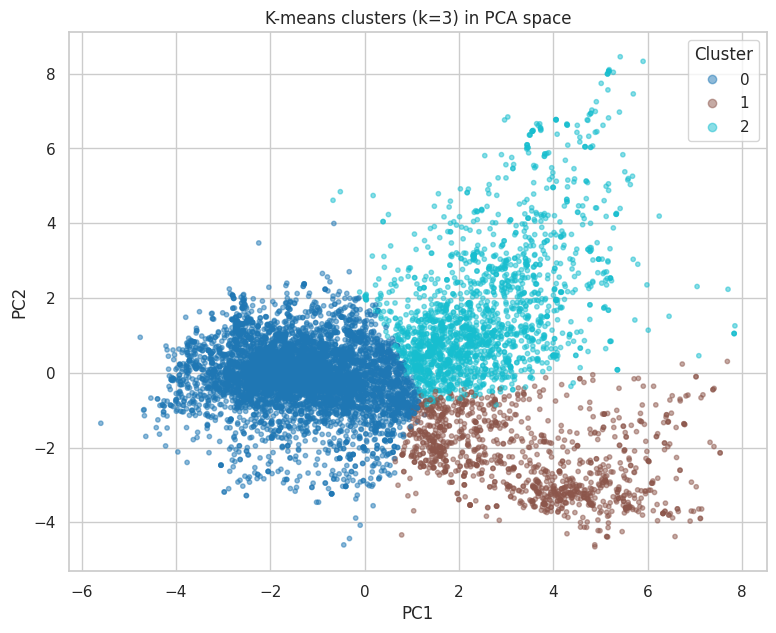

,size,displacement_ccm,power_hp,torque_nm,top_speed_kmh,dry_weight_kg,fuel_capacity_l,seat_height_mm,wheelbase_mm,bore_mm,stroke_mm,compression_ratio,power_weight_ratio,power_rpm
cluster,,,,,,,,,,,,,,
0,6705,235.5,16.6,18.3,101.9,126.7,10.0,811.8,1379.0,62.2,57.6,9.8,0.1,7461.9
1,1169,1370.4,76.0,113.9,151.5,288.7,17.4,688.7,1656.9,94.1,95.5,9.6,0.3,5670.6
2,1968,936.6,110.0,95.3,225.6,191.1,17.4,818.8,1468.8,88.6,64.9,11.8,0.6,9193.0


category,Allround,Classic,Custom / cruiser,Enduro / offroad,Naked bike,Scooter,Sport,Super motard
cluster,,,,,,,,
0,0.12,0.03,0.06,0.19,0.06,0.34,0.15,0.06
1,0.03,0.08,0.79,0.00,0.05,0.02,0.02,0.00
2,0.09,0.05,0.03,0.10,0.32,0.01,0.32,0.07


In [22]:
# ----- 4.4 用選定的 k 做 K-means，用 PCA 投影到 2D 視覺化，並描述各群特性 -----
km = KMeans(best_k, n_init=10, random_state=RANDOM_STATE).fit(Xs)
model_df = model_df.copy()
model_df["cluster"] = km.labels_                  # 把分群結果存回去
# PCA 把 13 維壓成 2 維好畫圖
pcs = PCA(2, random_state=RANDOM_STATE).fit_transform(Xs)
plt.figure(figsize=(9, 7))
sc = plt.scatter(pcs[:, 0], pcs[:, 1], c=km.labels_, cmap="tab10", s=10, alpha=.5)
plt.legend(*sc.legend_elements(), title="Cluster")
plt.title(f"K-means clusters (k={best_k}) in PCA space")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()
# 各群的平均規格(用來解讀每群是什麼樣的車)
prof = model_df.groupby("cluster")[MODEL_FEATURES].mean().round(1)
prof.insert(0, "size", model_df.cluster.value_counts().sort_index())  # 每群幾台車
display(prof)
# 各群裡各車種的占比(驗證分群是否對應真實車種)
display(pd.crosstab(model_df.cluster, model_df.category, normalize="index").round(2))

In [23]:
# ----- 4.5 關聯規則：用 Apriori 找「規格 -> 車種」的設計法則 -----
from mlxtend.frequent_patterns import apriori, association_rules
# 把數值規格用「三分位」切成 低/中/高 三級，轉成像「displacement_ccm=High」的項目
items = pd.DataFrame(index=model_df.index)
for c in ["displacement_ccm","power_hp","dry_weight_kg","top_speed_kmh","fuel_capacity_l","seat_height_mm"]:
    try:
        items[c] = c + "=" + pd.qcut(model_df[c], 3, labels=["Low","Med","High"]).astype("string")
    except ValueError:
        pass                                       # 若無法切三等分就略過
# 類別欄位直接當項目
for c in ["category","cooling","transmission","fuel_system"]:
    items[c] = c + "=" + model_df[c].astype("string")

# 市場籃編碼：每台車「只放入它有值的項目」(缺失就不放，這樣不會丟掉整列)
long = items.reset_index().melt(id_vars="index", value_name="item").dropna(subset=["item"])
onehot = pd.crosstab(long["index"], long["item"]).astype(bool)   # 轉成 True/False 的項目表
# Apriori 找頻繁項目集(支持度>=5%，項目集最多 3 項，避免規則太冗長)
freq = apriori(onehot, min_support=0.05, use_colnames=True, max_len=3)
# 由頻繁項目集產生關聯規則，以 lift(提升度) 衡量
try:
    rules = association_rules(freq, metric="lift", min_threshold=1.2)
except TypeError:
    rules = association_rules(freq, metric="lift", min_threshold=1.2, num_itemsets=len(onehot))
# 只保留精簡好讀的規則：信賴度>=0.6、lift>=1.2、前件<=2 項、後件=1 項
rules = rules[(rules.confidence >= .6) & (rules.lift >= 1.2)
              & (rules.antecedents.apply(len) <= 2) & (rules.consequents.apply(len) == 1)]
rules["antecedents"] = rules.antecedents.apply(lambda s: ", ".join(sorted(s)))  # 前件(條件)
rules["consequents"] = rules.consequents.apply(lambda s: ", ".join(sorted(s)))  # 後件(結果)
print(f"交易筆數={len(onehot)}, 符合條件的規則數={len(rules)}")
# 依 lift 由大到小，顯示前 15 條(support=支持度, confidence=信賴度, lift=提升度)
rules.drop_duplicates(["antecedents","consequents"]).sort_values("lift", ascending=False)[
    ["antecedents","consequents","support","confidence","lift"]].head(15).reset_index(drop=True)

交易筆數=9842, 符合條件的規則數=410


,antecedents,consequents,support,confidence,lift
0,"displacement_ccm=High, transmission=Belt",category=Custom / cruiser,0.060354,0.863372,6.113171
1,"displacement_ccm=High, seat_height_mm=Low",category=Custom / cruiser,0.091343,0.780382,5.525553
2,"dry_weight_kg=High, transmission=Belt",category=Custom / cruiser,0.060658,0.742537,5.257592
3,"dry_weight_kg=High, seat_height_mm=Low",category=Custom / cruiser,0.097338,0.741486,5.250148
4,"fuel_capacity_l=High, seat_height_mm=Low",category=Custom / cruiser,0.058626,0.717662,5.081458
5,"dry_weight_kg=Low, seat_height_mm=High",category=Enduro / offroad,0.074883,0.744444,4.884548
6,"displacement_ccm=Med, seat_height_mm=High",category=Enduro / offroad,0.068482,0.732609,4.806890
7,"fuel_capacity_l=Low, seat_height_mm=High",category=Enduro / offroad,0.057102,0.677925,4.448093
8,"cooling=Liquid, dry_weight_kg=Low",category=Enduro / offroad,0.070514,0.652869,4.283693
9,"displacement_ccm=Low, transmission=Belt",category=Scooter,0.099878,0.978109,4.187278


## 5. 進階統計檢定補充 — *對應課程「檢定武器庫」*

依「資料型態」補上常用檢定：單樣本 t、成對檢定三兄弟(t/Wilcoxon/符號)、雙樣本比例 z 檢定、卡方適合度。
(One-Way ANOVA、Tukey、Mann-Whitney、Kruskal、卡方獨立性已在第 3 節完成。)

In [24]:
# ----- 5.1 單樣本 t 檢定：全體機車的平均「評分」是否不等於中性值 3.0 -----
# H0: 平均評分 = 3.0(視 3.0 為中性);  對立 H1: != 3.0
from scipy import stats
r = df["rating"].dropna()
t1, p1 = stats.ttest_1samp(r, popmean=3.0)                 # 單樣本 t 檢定
ci = stats.t.interval(0.95, len(r)-1, loc=r.mean(), scale=stats.sem(r))  # 平均的 95% 信賴區間
print(f"n={len(r)}, 平均評分={r.mean():.3f}")
print(f"單樣本 t={t1:.1f}, p={p1:.2e}, 95%CI=({ci[0]:.3f}, {ci[1]:.3f})")
print("結論：平均評分顯著高於 3.0 -> 使用者整體評價偏正面。")

n=23513, 平均評分=3.413
單樣本 t=167.4, p=0.00e+00, 95%CI=(3.408, 3.418)
結論：平均評分顯著高於 3.0 -> 使用者整體評價偏正面。


n=31783, 平均(缸徑-行程)=8.03 mm
(a)成對t : t=104.4, p=0.00e+00
(b)Wilcoxon: W=91622282, p=0.00e+00
(c)符號檢定: 21061/30158 台 bore>stroke, p=0.00e+00
三法一致 -> 引擎平均為『大口徑短行程(oversquare)』,偏高轉取向。


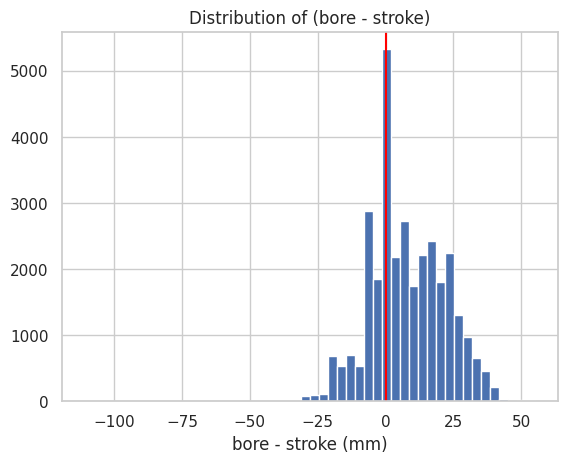

In [25]:
# ----- 5.2 成對樣本檢定：同一具引擎的「缸徑 bore」vs「行程 stroke」 -----
# 機械意義：bore>stroke=大口徑短行程(高轉取向)；bore<stroke=長行程(低轉扭力取向)
# 這是「同一台車上的兩個量測值」,屬於成對(paired)設計,故可用以下三種成對檢定
pair = df[["bore_mm","stroke_mm"]].dropna()
diff = pair["bore_mm"] - pair["stroke_mm"]
tt, pt = stats.ttest_rel(pair["bore_mm"], pair["stroke_mm"])          # (a)成對 t 檢定(有母數)
w,  pw = stats.wilcoxon(pair["bore_mm"], pair["stroke_mm"])           # (b)Wilcoxon 符號秩(無母數)
n_pos = int((diff > 0).sum()); n_eff = int((diff != 0).sum())        # (c)符號檢定:只看正負號
sign_p = stats.binomtest(n_pos, n_eff, 0.5).pvalue                    #    用二項檢定 比例是否=0.5
print(f"n={len(pair)}, 平均(缸徑-行程)={diff.mean():.2f} mm")
print(f"(a)成對t : t={tt:.1f}, p={pt:.2e}")
print(f"(b)Wilcoxon: W={w:.0f}, p={pw:.2e}")
print(f"(c)符號檢定: {n_pos}/{n_eff} 台 bore>stroke, p={sign_p:.2e}")
print("三法一致 -> 引擎平均為『大口徑短行程(oversquare)』,偏高轉取向。")
plt.hist(diff, bins=50, color="#4C72B0"); plt.axvline(0, color="red")
plt.title("Distribution of (bore - stroke)"); plt.xlabel("bore - stroke (mm)"); plt.show()

In [26]:
# ----- 5.3 雙樣本比例檢定：新世代(>=2010) vs 舊世代(<2010) 的「噴射供油比例」 -----
# H0: 兩個世代採用噴射的比例相等
from statsmodels.stats.proportion import proportions_ztest
sub = df.dropna(subset=["year","fuel_system"])
sub = sub[sub["fuel_system"].isin(["Injection","Carburettor"])]
modern = sub[sub.year >= 2010]; older = sub[sub.year < 2010]
counts = [int((modern.fuel_system == "Injection").sum()), int((older.fuel_system == "Injection").sum())]
nobs   = [len(modern), len(older)]
z, pz = proportions_ztest(counts, nobs)                    # 雙樣本比例 z 檢定
print(f"新世代噴射比例={counts[0]/nobs[0]:.1%} (n={nobs[0]}) | 舊世代={counts[1]/nobs[1]:.1%} (n={nobs[1]})")
print(f"z={z:.1f}, p={pz:.2e} -> 噴射在新世代顯著普及。")

新世代噴射比例=64.0% (n=5290) | 舊世代=22.7% (n=2553)
z=34.3, p=4.29e-258 -> 噴射在新世代顯著普及。


In [27]:
# ----- 5.4 卡方適合度檢定：三種冷卻方式是否「等比例」出現 -----
# H0: Air / Liquid / Oil & air 各佔 1/3 (均勻分布)
obs = df["cooling"].value_counts().reindex(["Air","Liquid","Oil & air"]).dropna()
exp = [obs.sum()/len(obs)] * len(obs)                      # 期望次數(均勻)
chi, pg = stats.chisquare(obs.values, exp)                 # 卡方適合度檢定
print("觀察次數:", dict(obs))
print(f"chi2={chi:.1f}, p={pg:.2e} -> 三種冷卻方式分布顯著不均(氣冷與水冷遠多於油冷)。")

觀察次數: {'Air': np.int64(18206), 'Liquid': np.int64(18223), 'Oil & air': np.int64(1781)}
chi2=14135.6, p=0.00e+00 -> 三種冷卻方式分布顯著不均(氣冷與水冷遠多於油冷)。


## 6. 進階資料採礦補充 — *對應課程「資料探勘與 ML 觀念」*

補上：降維的進一步解讀(陡坡圖/負荷)、**類別不平衡**處理、**資料外洩**的錯誤vs正確示範、
以及用 **RMSE/MAE** 評估的預測型迴歸。

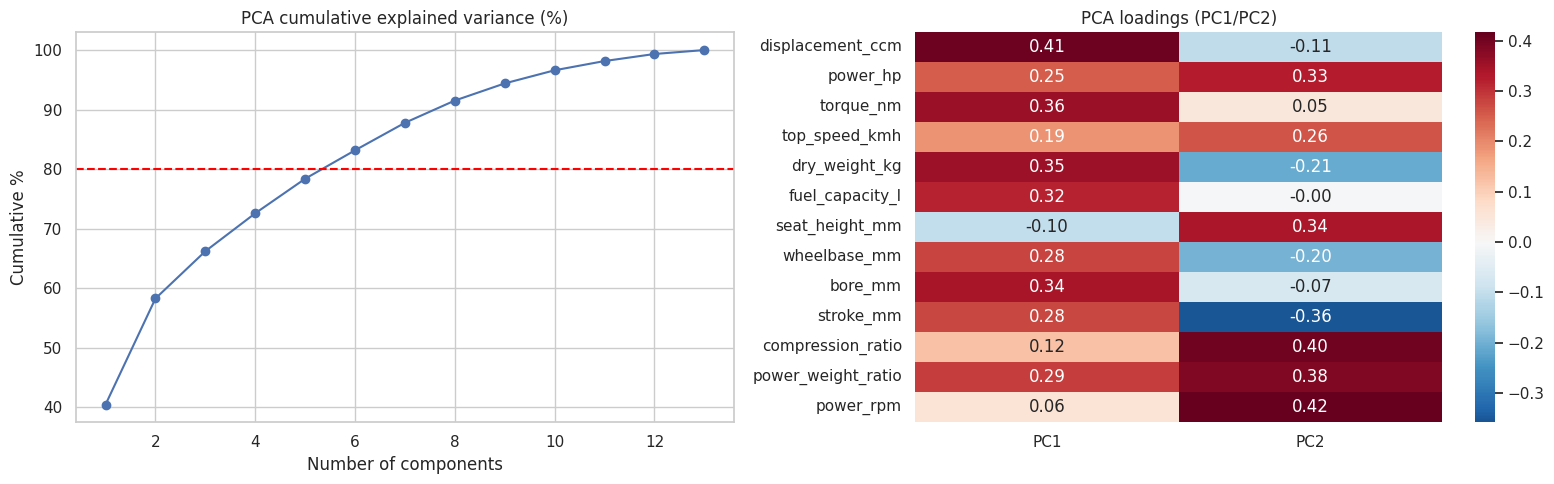

前 2 主成分共解釋 58.3% 的變異;PC1 多由排氣量/扭力/車重等『體型動力』規格主導。


In [28]:
# ----- 6.1 降維補充：PCA 累積解釋變異(陡坡圖) + 主成分負荷(loadings) -----
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Xc = model_df[MODEL_FEATURES].fillna(model_df[MODEL_FEATURES].median(numeric_only=True))
Xs = StandardScaler().fit_transform(Xc)
pca_full = PCA().fit(Xs)
ev = pca_full.explained_variance_ratio_                    # 每個主成分解釋的變異比例
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(range(1, len(ev)+1), ev.cumsum()*100, "o-")     # 累積解釋變異
ax[0].axhline(80, color="red", ls="--"); ax[0].set_title("PCA cumulative explained variance (%)")
ax[0].set_xlabel("Number of components"); ax[0].set_ylabel("Cumulative %")
load = pd.DataFrame(pca_full.components_[:2].T, index=MODEL_FEATURES, columns=["PC1","PC2"])  # 前2主成分負荷
sns.heatmap(load, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("PCA loadings (PC1/PC2)")
fig.tight_layout(); plt.show()
print(f"前 2 主成分共解釋 {ev[:2].sum()*100:.1f}% 的變異;PC1 多由排氣量/扭力/車重等『體型動力』規格主導。")

In [29]:
# ----- 6.2 類別不平衡：用 class_weight='balanced' 改善少數車種的辨識 -----
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, recall_score
print("各車種數量(不平衡,最多 vs 最少差很多):")
print(model_df.category.value_counts().to_string())
def make_rf(balanced):
    # class_weight='balanced' 會讓少數類別的樣本權重變高,逼模型多注意它們
    return Pipeline([("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1,
              class_weight=("balanced" if balanced else None)))])
for tag, bal in [("預設     ", False), ("balanced", True)]:
    m = make_rf(bal).fit(Xtr, ytr); pr = m.predict(Xte)   # Xtr/Xte/ytr/yte 來自 4.1 的切分
    rec = recall_score(yte, pr, labels=["Super motard"], average="macro")
    print(f"{tag}: 整體 macro-F1={f1_score(yte, pr, average='macro'):.3f} | 少數類(Super motard)召回={rec:.3f}")
print("結論:balanced 通常提升少數車種的召回(recall),代價是整體準確率略降 -> 視目標取捨。")

各車種數量(不平衡,最多 vs 最少差很多):
category
Scooter             2299
Sport               1637
Enduro / offroad    1500
Custom / cruiser    1390
Naked bike          1117
Allround             999
Super motard         538
Classic              362


預設     : 整體 macro-F1=0.761 | 少數類(Super motard)召回=0.585


balanced: 整體 macro-F1=0.750 | 少數類(Super motard)召回=0.681
結論:balanced 通常提升少數車種的召回(recall),代價是整體準確率略降 -> 視目標取捨。


In [30]:
# ----- 6.3 資料外洩(data leakage)示範：錯誤做法 vs 正確做法 -----
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
# (錯誤) 先用「全部訓練資料」補值+標準化,再做交叉驗證 -> 驗證折的統計量被前處理偷看到
leaky = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(Xtr))
acc_leak = cross_val_score(LogisticRegression(max_iter=2000), leaky, ytr, cv=cv, scoring="accuracy").mean()
# (正確) 把前處理放進 Pipeline,只在每個訓練折學習,驗證折完全沒被看到
pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                 ("clf", LogisticRegression(max_iter=2000))])
acc_ok = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="accuracy").mean()
print(f"(錯誤)前處理用全資料   : CV 準確率={acc_leak:.4f}")
print(f"(正確)前處理在 Pipeline: CV 準確率={acc_ok:.4f}")
print(f"差距={acc_leak-acc_ok:+.4f}。中位數補值的洩漏很小,但同樣錯誤若用在『特徵選擇/SMOTE/目標編碼』會嚴重灌水。")

(錯誤)前處理用全資料   : CV 準確率=0.5644
(正確)前處理在 Pipeline: CV 準確率=0.5629
差距=+0.0015。中位數補值的洩漏很小,但同樣錯誤若用在『特徵選擇/SMOTE/目標編碼』會嚴重灌水。


n=13973 | 測試集 RMSE=17.6 km/h, MAE=9.4 km/h, R2=0.907
RMSE>=MAE(因為平方放大大誤差);兩者越小代表預測越準。


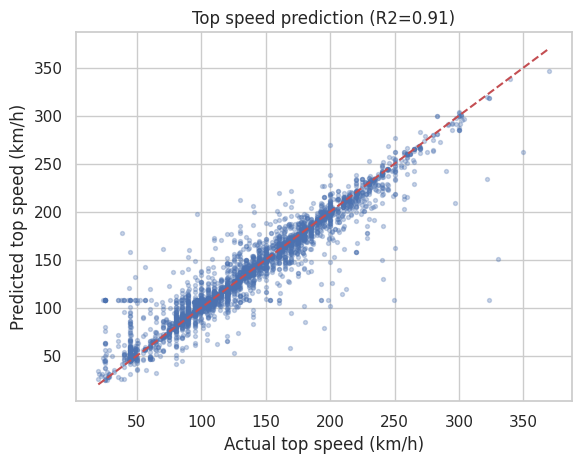

In [31]:
# ----- 6.4 預測型迴歸 + RMSE/MAE：用規格預測「極速」 -----
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
reg_df = df.dropna(subset=["top_speed_kmh"]).copy()
feat = [c for c in MODEL_FEATURES if c != "top_speed_kmh"]   # 注意:不可把答案(極速)放進特徵
Xr, yr = reg_df[feat], reg_df["top_speed_kmh"]
Xrtr, Xrte, yrtr, yrte = train_test_split(Xr, yr, test_size=0.25, random_state=RANDOM_STATE)
reg = Pipeline([("imp", SimpleImputer(strategy="median")),
                ("rf", RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1))]).fit(Xrtr, yrtr)
pred = reg.predict(Xrte)
rmse = root_mean_squared_error(yrte, pred)   # 均方根誤差(對大誤差較敏感)
mae  = mean_absolute_error(yrte, pred)       # 平均絕對誤差(較直觀)
r2   = r2_score(yrte, pred)
print(f"n={len(reg_df)} | 測試集 RMSE={rmse:.1f} km/h, MAE={mae:.1f} km/h, R2={r2:.3f}")
print("RMSE>=MAE(因為平方放大大誤差);兩者越小代表預測越準。")
plt.scatter(yrte, pred, s=8, alpha=.3)
lims = [yrte.min(), yrte.max()]; plt.plot(lims, lims, "r--")   # 紅線=完美預測
plt.xlabel("Actual top speed (km/h)"); plt.ylabel("Predicted top speed (km/h)"); plt.title(f"Top speed prediction (R2={r2:.2f})"); plt.show()

## 7. 結論 (Conclusions)

1. **冷卻方式 ⇒ 馬力**：水冷引擎平均馬力是氣冷的約 2.5 倍（Cohen's d = 1.03，大效應）。
2. **車種決定馬力**（ANOVA η² = 0.37），且**可由規格反推車種**（隨機森林準確率 79.8%）。
3. **資料印證物理**：極速 ∝ 馬力^0.43，接近空氣阻力的立方根定律（R² = 0.89）。
4. **自然存在三個市場區隔**（通勤小車 / 巡航重機 / 運動性能車），非監督分群即可還原。
5. **可解讀的設計法則**：{大排氣量＋皮帶傳動} ⇒ 巡航車（lift 6.1）；{小排氣量＋皮帶傳動} ⇒ 速可達（信賴度 0.98）。

> 完整文字報告、限制討論與程式碼自評：`CE5033_FinalProject/REPORT.md`